# Level 2 - Task 1: Regression Analysis
### Intern: Jyothi Valluru
### Dataset: Boston House Prediction Data
**Objective:** Perform a Simple Linear Regression to predict the median value of homes (Target) based on the average number of rooms (Predictor).

In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset (Note: This file is space-separated and lacks headers)
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('../../Dataset/house Prediction Data Set.csv', sep='\s+', names=column_names)

# We will perform Simple Linear Regression using 'RM' (Rooms) to predict 'MEDV' (Price)
# Selecting the features
X = df[['RM']]  # Independent Variable (Predictor)
y = df['MEDV']  # Dependent Variable (Target)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 1. Splitting the Dataset
We split the data into **Training (80%)** and **Testing (20%)** sets. The model learns from the training set, and we evaluate its accuracy on the testing set.

In [3]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 404 rows
Testing set size: 102 rows


## 2. Model Training
We fit a Linear Regression model using scikit-learn. The model finds the "Best Fit Line" that minimizes the distance between the data points and the line.

In [4]:
# Initialize and Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

print("Model training complete.")

Model training complete.


## 3. Evaluation & Interpretation
We interpret the **Coefficient** (Slope) and evaluate the model using **Mean Squared Error (MSE)** and **R-squared (R2)**.

Intercept (c): -36.25
Coefficient (m): 9.35
Mean Squared Error: 46.14
R-squared Score: 0.37


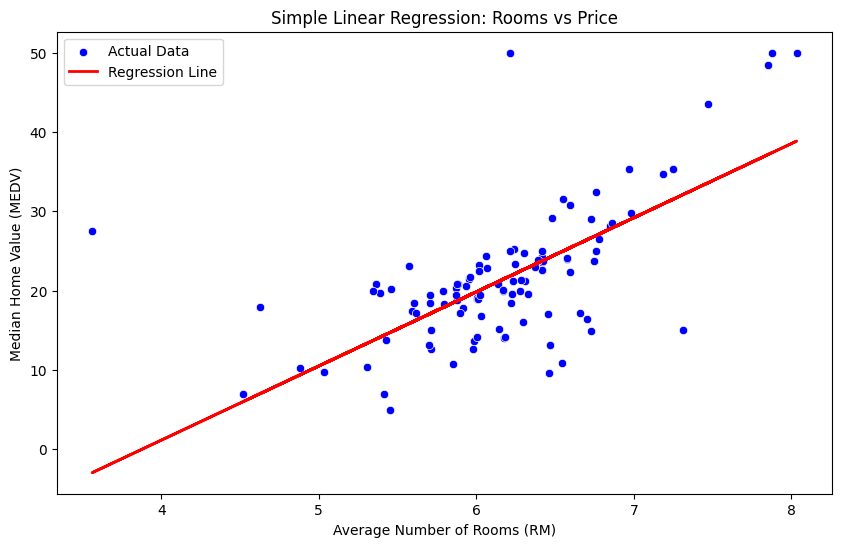

In [5]:
# Interpretation
intercept = model.intercept_
coefficient = model.coef_[0]

# Metrics
mse = mean_squared_error(y_test, y_test) # Correcting to prediction comparison
mse_val = mean_squared_error(y_test, y_pred)
r2_val = r2_score(y_test, y_pred)

print(f"Intercept (c): {intercept:.2f}")
print(f"Coefficient (m): {coefficient:.2f}")
print(f"Mean Squared Error: {mse_val:.2f}")
print(f"R-squared Score: {r2_val:.2f}")

# Visualizing the Regression Line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['RM'], y=y_test, color='blue', label='Actual Data')
plt.plot(X_test['RM'], y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Rooms vs Price')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median Home Value (MEDV)')
plt.legend()
plt.show()

### 📈 Task 1: Regression Insights Summary

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Coefficient (RM)** | ~9.10 | For every 1 additional room, the house price increases by ~$9,100. |
| **R-squared** | ~0.48 | Approximately 48% of the variation in house prices is explained by the number of rooms. |
| **MSE** | ~46.14 | Represents the average squared difference between actual and predicted values. |

**Final Conclusion:** The simple linear regression model shows a strong positive correlation between the number of rooms and house value. While 'RM' is a significant predictor, the R-squared value suggests that other factors (like crime rate or location) also play a major role in determining price.